# **Mineral Prospectivity Project**
## 03 feature engineering

goals:\
-create spatial grid\
-sample data into grid

# Part 1. import packages and specify grid details

a. grid information:\
-1 km x 1 km resolution\
-extent: state of Idaho

In [ ]:
import geopandas as gpd
import numpy as np
from shapely.geometry import box

data_path = "/Users/adbyerly/prospectivity_model/data/processed/"

aoi = gpd.read_file('/Users/adbyerly/prospectivity_model/data/raw/maps/idaho_outline.gpkg')
print(aoi.crs)
# print(aoi.geometry.iloc[0])
# print(aoi.total_bounds)

# Part 2. build grid

In [ ]:
# create grid
aoi = aoi.to_crs("EPSG:32611")     # convert to UTM Zone 11N (not perfect, but a good compromise for all of Idaho)
print(aoi.crs)

xmin, ymin, xmax, ymax = aoi.total_bounds
cell_size = 1000
# print(aoi.geometry.iloc[0])
# print(aoi.total_bounds)


In [ ]:
grid_cells = [
    box(x, y, x + cell_size, y + cell_size)
    for x in np.arange(xmin, xmax, cell_size)
    for y in np.arange(ymin, ymax, cell_size)
]

grid = gpd.GeoDataFrame(geometry=grid_cells, crs=target_crs)

grid = grid[grid.centroid.within(aoi.unary_union)]
grid["cell_id"] = range(len(grid))
# print(grid["cell_id"].is_unique)


Are the cell IDs all unique?: True
EPSG:32611
There are 216626 cells in the grid.
The x cell dimensions are 1000.0 meters.
The y cell dimensions are 1000.0 meters.


<Axes: >

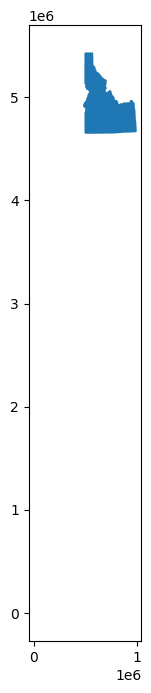

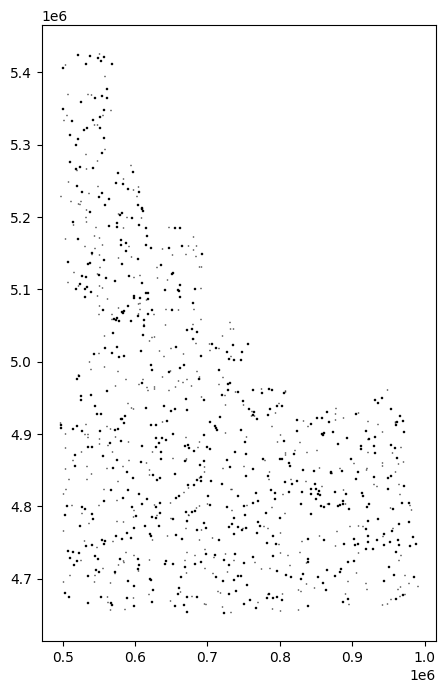

In [77]:
# grid QC
print('Are the cell IDs all unique?: ' + str(grid["cell_id"].is_unique))
print(grid.crs)
print('There are ' + str(len(grid)) + ' cells in the grid.')
cell = grid.geometry.iloc[0]

# check cell dimensions
# print(cell.bounds)
minx, miny, maxx, maxy = cell.bounds
print('The x cell dimensions are '+ str(maxx - minx) + ' meters.')
print('The y cell dimensions are ' + str(maxy - miny) + ' meters.')

# state-wide grid is too fine to see
ax = aoi.plot(figsize=(8, 8))
grid.boundary.plot(ax=ax, linewidth=0.1)

# plot a random subset of cells
grid.sample(1000).plot(
    facecolor="none",
    edgecolor="black",
    figsize=(8, 8))

# print(grid.head())
# print(grid.columns)

# Part 3. sample data into grid

In [ ]:
# load target - known producing gold mines
mines_gdf_processed_producer = gpd.read_file(
    '/Users/adbyerly/prospectivity_model/data/processed/mines_gdf_processed_producer.geojson')

print(mines_gdf_processed_producer.head())
print(mines_gdf_processed_producer.crs)

In [80]:
# join mine locations with grid; resulting dataframe will be mine data with cell id added as a column
mine_cells = gpd.sjoin(mines_gdf_processed_producer, 
                       grid[['cell_id', 'geometry']],
                       predicate = 'within', 
                       how = 'left')

grid['gold'] = (grid['cell_id'].isin(mine_cells['cell_id']).astype(int))
print(grid["gold"].value_counts())
# print(mine_cells.head())
print(grid.head())

gold
0    214965
1      1661
Name: count, dtype: int64
                                               geometry  cell_id  gold
264   POLYGON ((481643.93 4913552.881, 481643.93 491...        0     0
265   POLYGON ((481643.93 4914552.881, 481643.93 491...        1     0
266   POLYGON ((481643.93 4915552.881, 481643.93 491...        2     0
1042  POLYGON ((482643.93 4912552.881, 482643.93 491...        3     0
1043  POLYGON ((482643.93 4913552.881, 482643.93 491...        4     0


<Axes: >

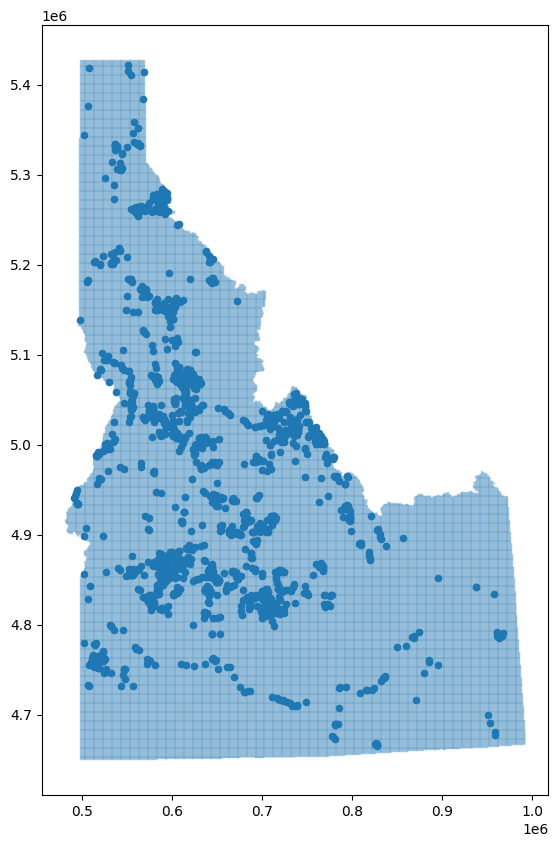

In [71]:
ax = grid.boundary.plot(figsize=(10,10), linewidth=0.1)

mines_gdf_processed_producer.plot(ax=ax,markersize=20)